In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/FORS2.2021-08-22T09_05_48.342.fits") #image
hdul2 = fits.open("UGC-3141_MAPPED_FLUX_SCI_LSS_U1.fits") #spectrum
image_data = hdul[0].data
image_data_2 = hdul2[0].data
image_error_2 = hdul2[1].data

In [4]:
image_cut = image_data[93:213, 1026:1196]
image_cut_2 = image_data_2[90:210, 0:1890] 
image_error_cut_2 = image_error_2[90:210, 0:1890]

In [5]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, params):
    """ Profilo Sérsic 1D centrato in x_0 """
    I_e, r_e, n, x_0 = params
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, params1, params2, params3):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, params1) +
        sersic_1d(x_hr, params2) +
        sersic_1d(x_hr, params3) #+
        #sersic_1d(x_hr, *params[12:16]) #+
        #sersic_1d(x_hr, *params[16:20])+ 
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def sersic_1d_convolved(x, sigma, params):
    """ Sérsic convoluto con PSF gaussiana """
    I_e, r_e, n, x_0 = params
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, params)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

In [6]:
z = 0.03401
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/PSF/Real_seeing_UGC3141.txt")
sigmas = seeing / 2.35

wavelenghts = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
mask_HA = (wavelenghts > l_HA-8)*(wavelenghts < l_HA+8)
image_HA = image_cut_2[:, mask_HA]
image_error_HA = image_error_cut_2[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))
sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/Propagazione_errore/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 120, 1)
fit = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/Fit/Halpha_fit.csv", index_col=0)

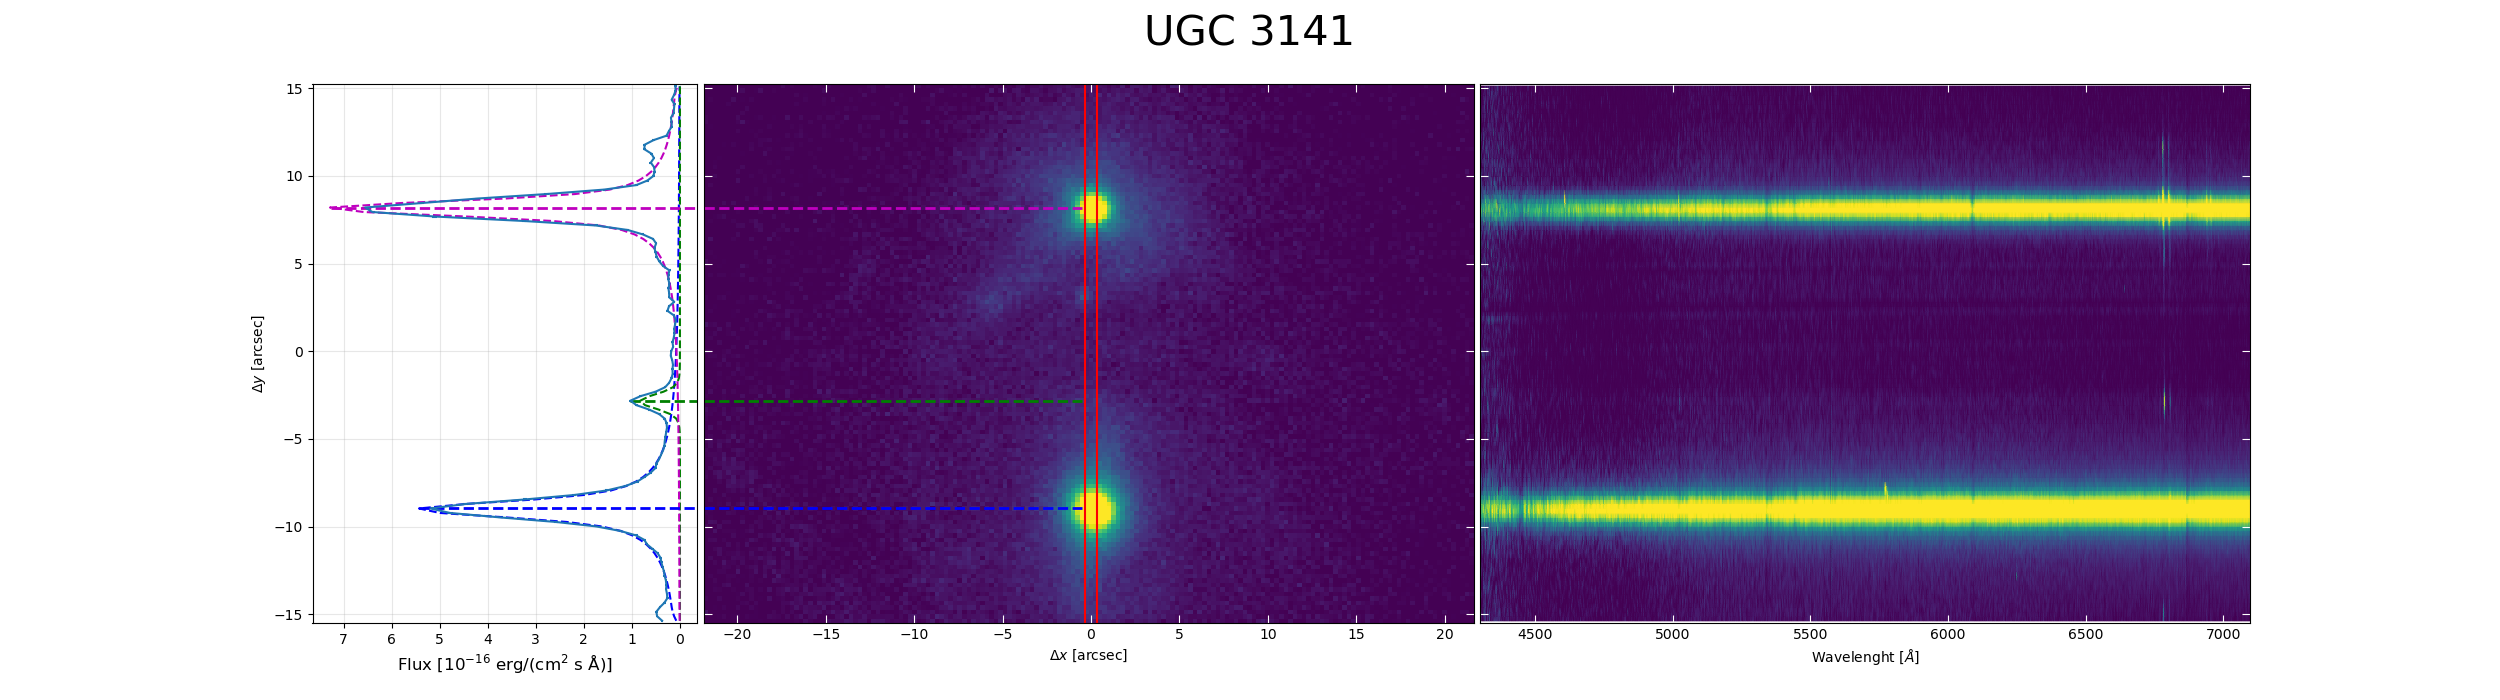

In [7]:
arcsec_x = np.arange(-85*0.256, 85*0.256, 0.256)
arcsec_y = np.arange(-60*0.256, 60*0.256, 0.256)
#x_grid, y_grid = np.meshgrid(arcsec_x, arcsec_y)
#x_grid_2, y_grid_2 = np.meshgrid(wavelenghts, arcsec_y)
J, N = image_cut.shape
x = np.arange(0, N, 1)
y = np.arange(0, J, 1)

x_grid, y_grid = np.meshgrid(arcsec_x, arcsec_y)

J_2, N_2 = image_cut_2.shape
x_2 = np.arange(0, N_2, 1)
y_2 = np.arange(0, J_2, 1)

x_grid_2, y_grid_2 = np.meshgrid(wavelenghts, arcsec_y)

y_fit = model_convolved(x_axes, sigmas[0], fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'])

fig, ax = plt.subplots(1, 3, figsize=(25, 7), 
                      gridspec_kw={'width_ratios': [1, 2, 2], 'wspace': 0.01},
                      sharey=True)
fig.suptitle('UGC 3141', fontsize=30)

ax[0].errorbar(radial_profile_HA, arcsec_y, xerr = radial_profile_error_HA, label='Data')

colors = ['b', 'g', 'm'] 
components = ['Component 1', 'Component 2', 'Component 3']
for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(x_axes, sigmas[0], np.array(fit[comp_name]))
        ax[0].plot(y_comp, arcsec_y, '--', color=color,  
                  label=f'Sérsic {i+1}')
    
ax[0].set_xlabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
#ax[0].legend(loc='upper right', fontsize=13)
ax[0].grid(True, alpha=0.3)
ax[0].invert_xaxis()
xlim = ax[0].get_xlim()
ax[0].hlines(y=-8.96, xmin=5.42, xmax = xlim[1],  color='blue', linewidth=2, linestyle = '--')
ax[0].hlines(y=-2.86, xmin=1.04, xmax = xlim[1],  color='g', linewidth=2, linestyle = '--')
ax[0].hlines(y=8.19, xmin=7.26, xmax = xlim[1],  color='m', linewidth=2, linestyle = '--')
ax[0].set_xlim(xlim[0], xlim[1])

ax[1].pcolormesh(x_grid, y_grid, np.log10(image_cut), shading='nearest', vmin=np.log10(3000), vmax=np.log10(7000), cmap = 'viridis') #hot: 2500, 6000
ax[1].set_xlabel(r'$\Delta x$ [arcsec]')
ax[0].set_ylabel(r'$\Delta y$ [arcsec]')
ax[1].axvline(-0.35, color='red')
ax[1].axvline(0.35, color='red')
ax[1].tick_params(axis='both', which='both', direction='in', color = 'white', top=True, bottom=True, left=True, right=True, length = 6)
xlim = ax[1].get_xlim()
ax[1].hlines(y=-8.96, xmin =xlim[0],  xmax=-0.5, color='blue', linewidth=2, linestyle = '--')
ax[1].hlines(y=-2.86, xmin =xlim[0],  xmax=-0.5, color='g', linewidth=2, linestyle = '--')
ax[1].hlines(y=8.19, xmin =xlim[0],  xmax=-0.5, color='m', linewidth=2, linestyle = '--')
ax[1].set_xlim(xlim[0], xlim[1])

ax[2].pcolormesh(x_grid_2, y_grid_2, image_cut_2, shading='gouraud', vmin=np.percentile(image_cut_2, 20), vmax=np.percentile(image_cut_2, 95)) #altre opzioni
ax[2].set_xlabel(r'Wavelenght [$\AA$]')
ax[2].tick_params(axis='both', which='both', direction='in', color = 'white', top=True, bottom=True, left=True, right=True, length = 6)
plt.subplots_adjust(wspace=0.01)

fig.savefig("UGC3141_all.png")